# AI-Powered Travel Recommendation System

## Project Overview

This project develops an intelligent travel recommendation system using:
- Machine Learning
- Natural Language Processing (NLP)
- Hybrid Recommendation Systems
- Data Analytics

The system recommends destinations based on:
- destination similarity
- travel season
- popularity
- user ratings

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Objectives
- Perform tourism data analysis
- Build hybrid recommendation engine
- Generate intelligent travel suggestions
- Create scalable recommendation architecture

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Plot settings
plt.rcParams['figure.figsize'] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# Load datasets

destinations = pd.read_csv(r"C:\Users\debas\Downloads\travel project kaggle\Expanded_Destinations.csv")

reviews = pd.read_csv(r"C:\Users\debas\Downloads\travel project kaggle\Final_Updated_Expanded_Reviews.csv")

user_history = pd.read_csv(r"C:\Users\debas\Downloads\travel project kaggle\Final_Updated_Expanded_UserHistory.csv")

users = pd.read_csv(r"C:\Users\debas\Downloads\travel project kaggle\Final_Updated_Expanded_Users.csv")


print("Datasets loaded successfully.")

Datasets loaded successfully.


In [8]:
print("Destinations Shape:", destinations.shape)
print("Reviews Shape:", reviews.shape)
print("User History Shape:", user_history.shape)
print("Users Shape:", users.shape)

Destinations Shape: (1000, 6)
Reviews Shape: (999, 5)
User History Shape: (999, 5)
Users Shape: (999, 7)


In [9]:
display(destinations.head())
display(reviews.head())
display(user_history.head())
display(users.head())

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,8.691906,Nov-Feb
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar
2,3,Jaipur City,Rajasthan,City,9.225372,Oct-Mar
3,4,Kerala Backwaters,Kerala,Nature,7.977386,Sep-Mar
4,5,Leh Ladakh,Jammu and Kashmir,Adventure,8.399822,Apr-Jun


,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,178,327,2,Incredible monument!
1,2,411,783,1,Loved the beaches!
2,3,927,12,2,A historical wonder
3,4,358,959,3,Incredible monument!
4,5,989,353,2,Loved the beaches!


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,525,760,2024-01-01,3
1,2,184,532,2024-02-15,5
2,3,897,786,2024-03-20,2
3,4,470,660,2024-01-01,1
4,5,989,389,2024-02-15,4


,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Kavya,kavya@example.com,"Beaches, Historical",Female,1,0
1,2,Rohan,rohan@example.com,"Nature, Adventure",Male,2,2
2,3,Kavya,kavya@example.com,"City, Historical",Female,2,0
3,4,Anika,anika@example.com,"Beaches, Historical",Female,1,0
4,5,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2,2


In [10]:
print(destinations.info())
print(reviews.info())
print(user_history.info())
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DestinationID    1000 non-null   int64  
 1   Name             1000 non-null   object 
 2   State            1000 non-null   object 
 3   Type             1000 non-null   object 
 4   Popularity       1000 non-null   float64
 5   BestTimeToVisit  1000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 47.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ReviewID       999 non-null    int64 
 1   DestinationID  999 non-null    int64 
 2   UserID         999 non-null    int64 
 3   Rating         999 non-null    int64 
 4   ReviewText     999 non-null    object
dtypes: int64(4), object(1)
memory usage: 39.2+ KB
Non

In [11]:
print(destinations.isnull().sum())
print(reviews.isnull().sum())
print(user_history.isnull().sum())
print(users.isnull().sum())

DestinationID      0
Name               0
State              0
Type               0
Popularity         0
BestTimeToVisit    0
dtype: int64
ReviewID         0
DestinationID    0
UserID           0
Rating           0
ReviewText       0
dtype: int64
HistoryID           0
UserID              0
DestinationID       0
VisitDate           0
ExperienceRating    0
dtype: int64
UserID              0
Name                0
Email               0
Preferences         0
Gender              0
NumberOfAdults      0
NumberOfChildren    0
dtype: int64


In [12]:
# Remove duplicates

destinations.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)
user_history.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)

# Convert date column

user_history['VisitDate'] = pd.to_datetime(
    user_history['VisitDate']
)

# Standardize text

destinations['Name'] = (
    destinations['Name']
    .str.strip()
    .str.title()
)

destinations['State'] = (
    destinations['State']
    .str.strip()
    .str.title()
)

destinations['Type'] = (
    destinations['Type']
    .str.strip()
    .str.title()
)

users['Preferences'] = (
    users['Preferences']
    .str.strip()
    .str.title()
)

print("Data cleaned successfully.")

Data cleaned successfully.


In [13]:
destinations_unique = destinations.drop_duplicates(
    subset=['Name', 'Type', 'State']
).copy()

destinations_unique.reset_index(
    drop=True,
    inplace=True
)

print(destinations_unique.shape)

(5, 6)


In [14]:
destination_popularity = reviews.groupby(
    'DestinationID'
).agg({
    'Rating': ['mean', 'count']
})

destination_popularity.columns = [
    'Average_Rating',
    'Rating_Count'
]

destination_popularity.reset_index(inplace=True)

display(destination_popularity.head())

,DestinationID,Average_Rating,Rating_Count
0,1,1.0,1
1,2,2.5,2
2,4,5.0,1
3,5,1.0,1
4,8,3.0,1


In [15]:
destinations_unique = destinations_unique.merge(
    destination_popularity,
    on='DestinationID',
    how='left'
)

display(destinations_unique.head())

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit,Average_Rating,Rating_Count
0,1,Taj Mahal,Uttar Pradesh,Historical,8.691906,Nov-Feb,1.0,1.0
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar,2.5,2.0
2,3,Jaipur City,Rajasthan,City,9.225372,Oct-Mar,NaN,NaN
3,4,Kerala Backwaters,Kerala,Nature,7.977386,Sep-Mar,5.0,1.0
4,5,Leh Ladakh,Jammu And Kashmir,Adventure,8.399822,Apr-Jun,1.0,1.0


In [17]:
scaler = MinMaxScaler()

destinations_unique[
    ['Popularity', 'Average_Rating']
] = scaler.fit_transform(
    destinations_unique[
        ['Popularity', 'Average_Rating']
    ]
)

In [18]:
destinations_unique['Weighted_Score'] = (
    destinations_unique['Average_Rating'] * 0.7 +
    destinations_unique['Popularity'] * 0.3
)

display(
    destinations_unique[
        ['Name', 'Weighted_Score']
    ].head()
)

,Name,Weighted_Score
0,Taj Mahal,0.171762
1,Goa Beaches,0.413378
2,Jaipur City,NaN
3,Kerala Backwaters,0.700000
4,Leh Ladakh,0.101548


In [19]:
destinations_unique['Features'] = (
    destinations_unique['Type'] + " " +
    destinations_unique['State'] + " " +
    destinations_unique['BestTimeToVisit']
)

display(
    destinations_unique[
        ['Name', 'Features']
    ].head()
)

,Name,Features
0,Taj Mahal,Historical Uttar Pradesh Nov-Feb
1,Goa Beaches,Beach Goa Nov-Mar
2,Jaipur City,City Rajasthan Oct-Mar
3,Kerala Backwaters,Nature Kerala Sep-Mar
4,Leh Ladakh,Adventure Jammu And Kashmir Apr-Jun


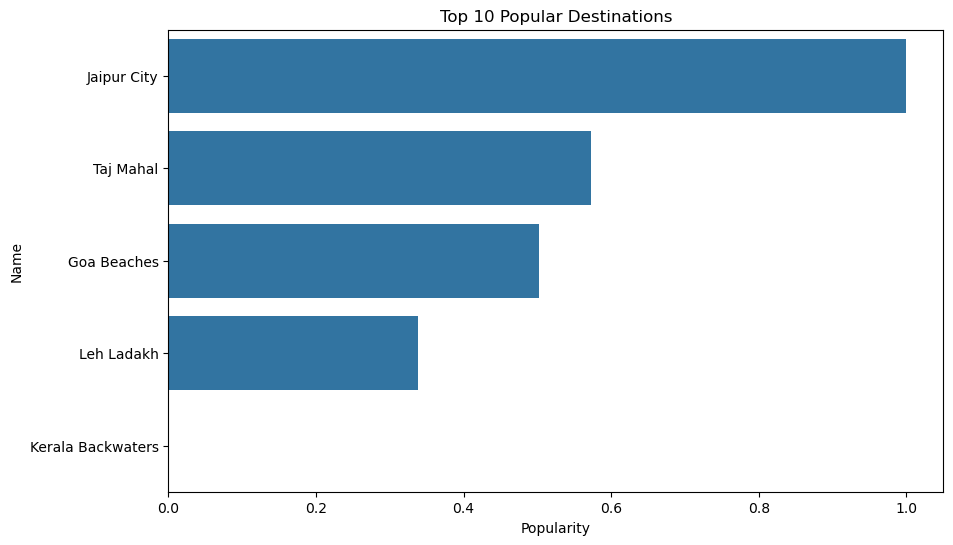

In [20]:
top_destinations = destinations_unique.sort_values(
    by='Popularity',
    ascending=False
).head(10)

sns.barplot(
    x='Popularity',
    y='Name',
    data=top_destinations
)

plt.title("Top 10 Popular Destinations")

plt.show()

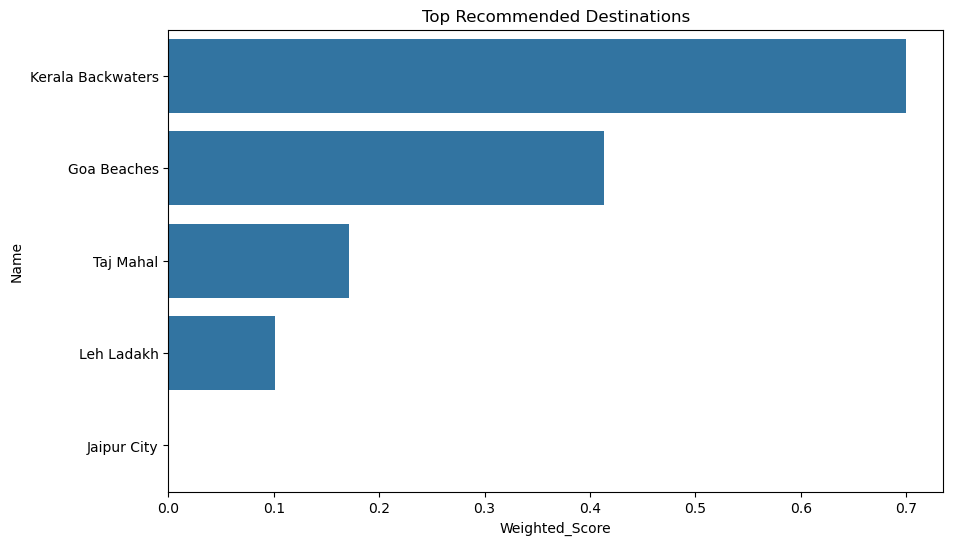

In [32]:
sns.barplot(
    x='Weighted_Score',
    y='Name',
    data=top_recommendations
)

plt.title("Top Recommended Destinations")

plt.show()

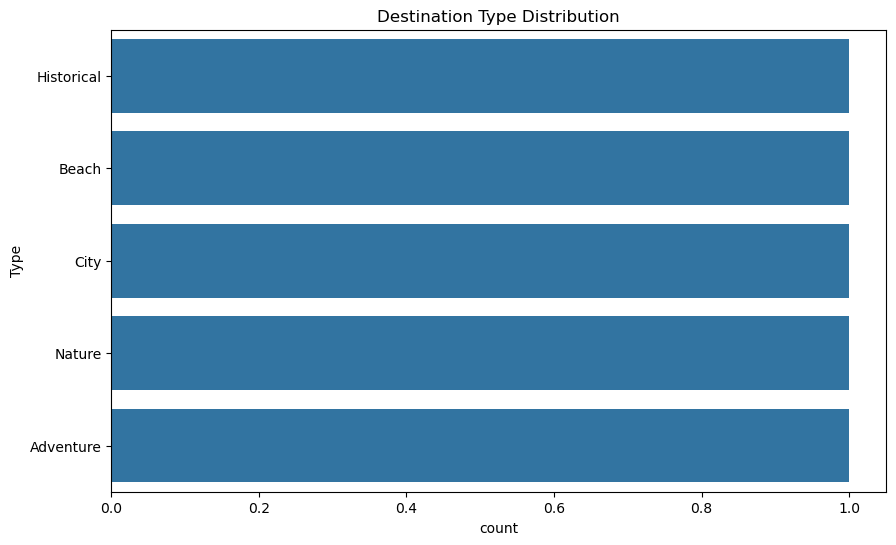

In [21]:
sns.countplot(
    y='Type',
    data=destinations_unique,
    order=destinations_unique[
        'Type'
    ].value_counts().index
)

plt.title("Destination Type Distribution")

plt.show()

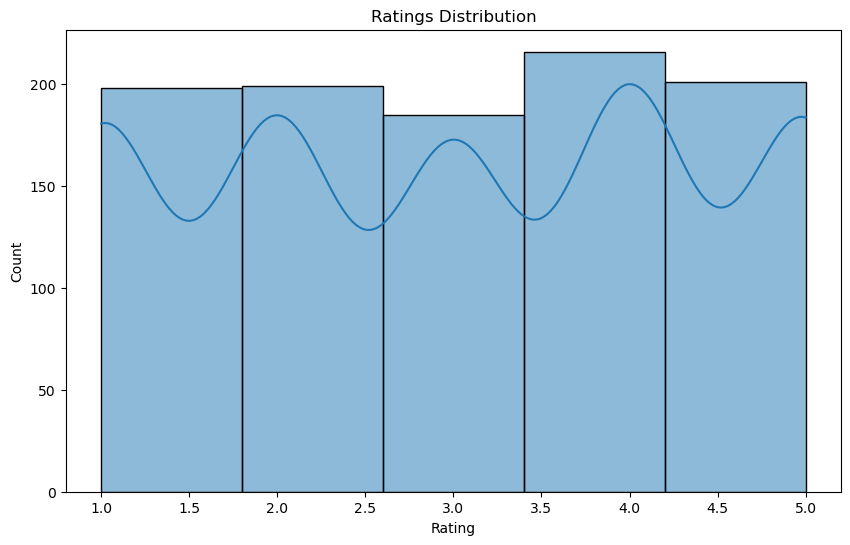

In [22]:
sns.histplot(
    reviews['Rating'],
    bins=5,
    kde=True
)

plt.title("Ratings Distribution")

plt.show()

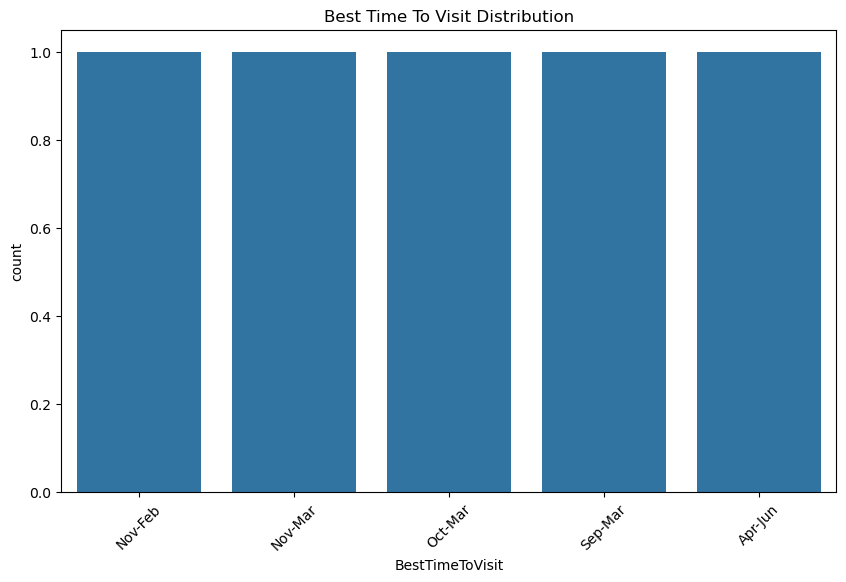

In [23]:
sns.countplot(
    x='BestTimeToVisit',
    data=destinations_unique,
    order=destinations_unique[
        'BestTimeToVisit'
    ].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Best Time To Visit Distribution")

plt.show()


In [24]:
tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    destinations_unique['Features']
)

print(tfidf_matrix.shape)

(5, 19)


In [25]:
cosine_sim = cosine_similarity(
    tfidf_matrix
)

print(cosine_sim.shape)

(5, 5)


In [27]:
indices = pd.Series(
    destinations_unique.index,
    index=destinations_unique['Name']
).drop_duplicates()

In [28]:
def recommend_destinations(name, cosine_sim=cosine_sim):

    name = name.title()

    if name not in indices:
        return "Destination not found."

    idx = indices[name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    destination_indices = [
        i[0] for i in similarity_scores
    ]

    recommendations = destinations_unique.iloc[
        destination_indices
    ][[
        'Name',
        'Type',
        'State',
        'BestTimeToVisit',
        'Average_Rating',
        'Weighted_Score'
    ]]

    recommendations['Similarity_Score'] = [
        i[1] for i in similarity_scores
    ]

    recommendations = recommendations.sort_values(
        by='Weighted_Score',
        ascending=False
    )

    return recommendations.drop_duplicates()

In [29]:
recommend_destinations("Goa Beaches")

,Name,Type,State,BestTimeToVisit,Average_Rating,Weighted_Score,Similarity_Score
3,Kerala Backwaters,Nature,Kerala,Sep-Mar,1.0,0.700000,0.137189
0,Taj Mahal,Historical,Uttar Pradesh,Nov-Feb,0.0,0.171762,0.171441
4,Leh Ladakh,Adventure,Jammu And Kashmir,Apr-Jun,0.0,0.101548,0.000000
2,Jaipur City,City,Rajasthan,Oct-Mar,NaN,NaN,0.137189


In [30]:
top_recommendations = destinations_unique.sort_values(
    by='Weighted_Score',
    ascending=False
).head(10)

display(
    top_recommendations[
        [
            'Name',
            'Type',
            'State',
            'Weighted_Score'
        ]
    ]
)

,Name,Type,State,Weighted_Score
3,Kerala Backwaters,Nature,Kerala,0.700000
1,Goa Beaches,Beach,Goa,0.413378
0,Taj Mahal,Historical,Uttar Pradesh,0.171762
4,Leh Ladakh,Adventure,Jammu And Kashmir,0.101548
2,Jaipur City,City,Rajasthan,NaN


# Future Improvements

Future enhancements for this system include:
- Streamlit web application
- User-personalized recommendations
- Sentiment analysis using review text
- Collaborative filtering
- Deep learning recommendation systems
- Travel budget prediction
- Weather API integration
- Google Maps integration

# Key Insights

- Beach and Adventure destinations are highly popular.
- Seasonal trends strongly influence recommendations.
- Hybrid recommendation systems improve recommendation quality.
- Feature engineering significantly enhanced destination ranking.

# Conclusion

This project successfully developed an advanced AI-powered travel recommendation system using:
- NLP
- TF-IDF Vectorization
- Cosine Similarity
- Feature Engineering
- Hybrid Recommendation Logic

The recommendation engine intelligently suggests destinations using:
- travel similarity
- popularity metrics
- user ratings
- seasonal preferences

This project demonstrates:
- Data Analytics
- Machine Learning
- Recommendation Systems
- NLP Applications
- Business Intelligence